In [ ]:
!pip install pymorphy3 -q
import pandas as pd
import numpy as np
import sklearn
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import os
from pathlib import Path
import joblib
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
import torch
from sklearn.metrics import accuracy_score,f1_score
import pymorphy3
from transformers import pipeline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 99.0 MB/s eta 0:00:00


In [ ]:
put = Path('/content/drive/MyDrive/test_data.parquet')# написать путь, где сохранен test_data
testdf = pd.read_parquet(put)

# Классика на новых данных

In [ ]:
vectorizer = joblib.load('/content/drive/MyDrive/tfidf_vector.joblib')
model = joblib.load('/content/drive/MyDrive/classic_model.joblib')
test_classic = testdf[['topic','text_lemma']].copy()

## Предобработка для тестовых данных

## Применение  классической модели

In [ ]:
X = vectorizer.transform(test_classic['text_lemma'])
test_classic['predicted_topic'] = model.predict(X)

Какие слова имели наибольший вес в пересекающихся классах:

In [ ]:
feature_names = vectorizer.get_feature_names_out()
classes = model.classes_
top_n = 10

top_words = {}
for i, cls in enumerate(classes):
    top_idx = np.argsort(model.coef_[i])[::-1][:top_n]
    top_words[cls] = feature_names[top_idx]

df_top = pd.DataFrame(top_words)
df_top[['Крым',"Бывший СССР","Бизнес","Экономика","Силовые структуры","Россия"]]

,Крым,Бывший СССР,Бизнес,Экономика,Силовые структуры,Россия
0,овсянников,украина,говориться,экономика,скр,песок
1,севастополь,как,компания,компания,сообщить,кремль
2,крыминформ,украинский,авиакомпания,индекс,jane,итар
3,писарев,киргизия,корпорация,минэкономразвития,минобороны,чечня
4,керченский,сообщать,отмечаться,нефть,оборона,путин
5,правительство,республика,бизнес,банк,источник,теракт
6,крым,delfi,роснано,сейчас,следствие,милиционер
7,рк,казахстан,работа,финансы,военный,каеда
8,референдум,рада,требование,инфляция,тип,курск
9,крымский,узбекистан,продукция,bloomberg,росгвардия,москва


# Bert на новых данных

In [ ]:
put_model = '/content/drive/MyDrive/bert_finetuned' # написать свой путь к папке bert_finetuned
put_token = '/content/drive/MyDrive/bert_token_finetuned' # написать свой путь к папке bert_token_finetuned
tokenizer = AutoTokenizer.from_pretrained(put_token)
model = AutoModelForSequenceClassification.from_pretrained(put_model)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(83828, 312, padding_idx=0)
      (position_embeddings): Embedding(2048, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, 

In [ ]:
classifier = pipeline('text-classification',model=model,tokenizer=tokenizer,device=0 if torch.cuda.is_available() else -1,truncation=True,max_length=256)
texts = testdf['text'].tolist()
results = classifier(texts, batch_size=48)
testdf['predicted_topic'] = [r['label'] for r in results]

In [ ]:
classes = sorted(testdf['topic'].unique())
id2label = {i: cls for i, cls in enumerate(classes)}

testdf['predicted_topic'] = [
    id2label[int(r['label'].replace('LABEL_', ''))]
    for r in results
]

#Результаты

In [ ]:
import warnings
warnings.filterwarnings("ignore")
print('Результат нейросетевого подхода:',classification_report(testdf['topic'],testdf['predicted_topic']),'Результат классического подхода:',classification_report(test_classic['topic'],test_classic['predicted_topic']),sep = '\n')

Результат нейросетевого подхода:
                   precision    recall  f1-score   support

   69-я параллель       0.54      0.81      0.65       254
           Бизнес       0.45      0.73      0.55      1480
      Бывший СССР       0.78      0.92      0.85     10680
              Дом       0.80      0.87      0.83      4347
         Из жизни       0.61      0.68      0.64      5521
   Интернет и СМИ       0.74      0.79      0.76      8933
             Крым       0.25      0.77      0.38       133
         Культура       0.83      0.94      0.88     10759
              Мир       0.86      0.78      0.82     27324
  Наука и техника       0.80      0.90      0.84     10627
      Путешествия       0.71      0.75      0.73      1282
           Россия       0.87      0.75      0.81     32088
Силовые структуры       0.69      0.69      0.69      3919
            Спорт       0.96      0.98      0.97     12883
         Ценности       0.89      0.84      0.87      1553
        Экономика     

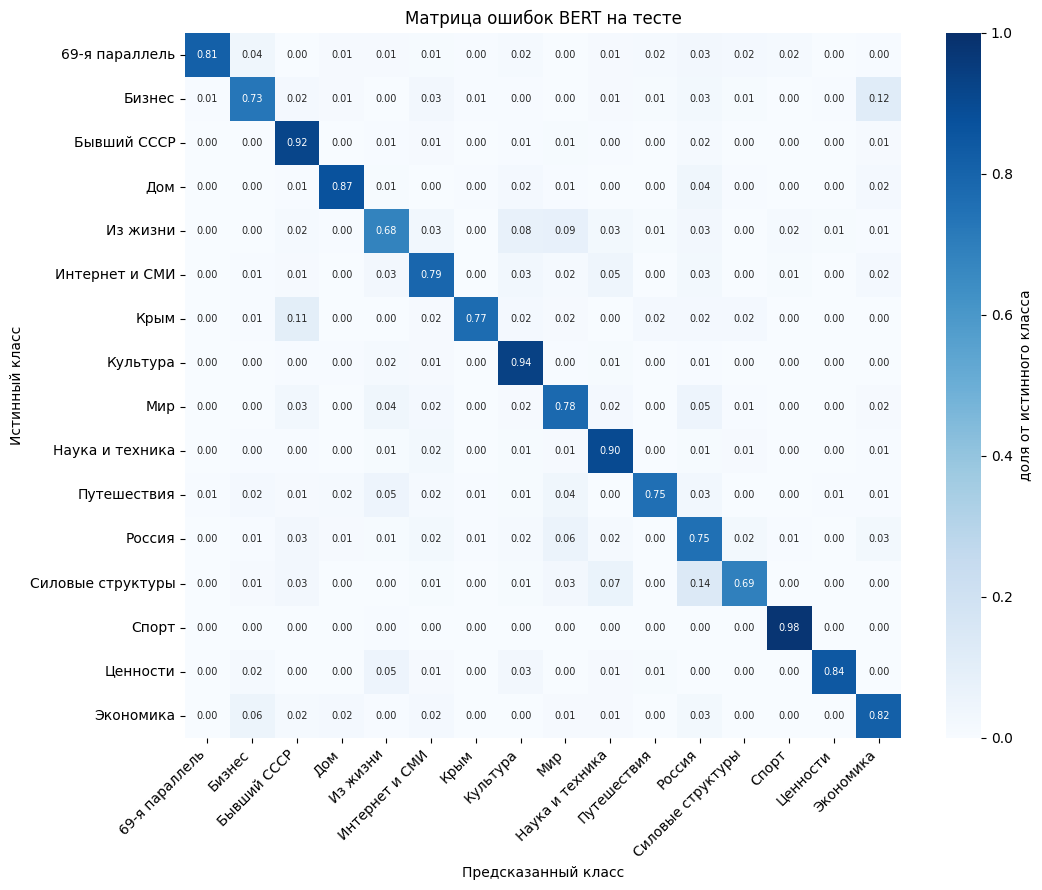

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(testdf['topic'], testdf['predicted_topic'], labels=classes, normalize='true')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size': 7},
            cbar_kws={'label': 'доля от истинного класса'}, ax=ax)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
ax.set_title('Матрица ошибок BERT на тесте')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

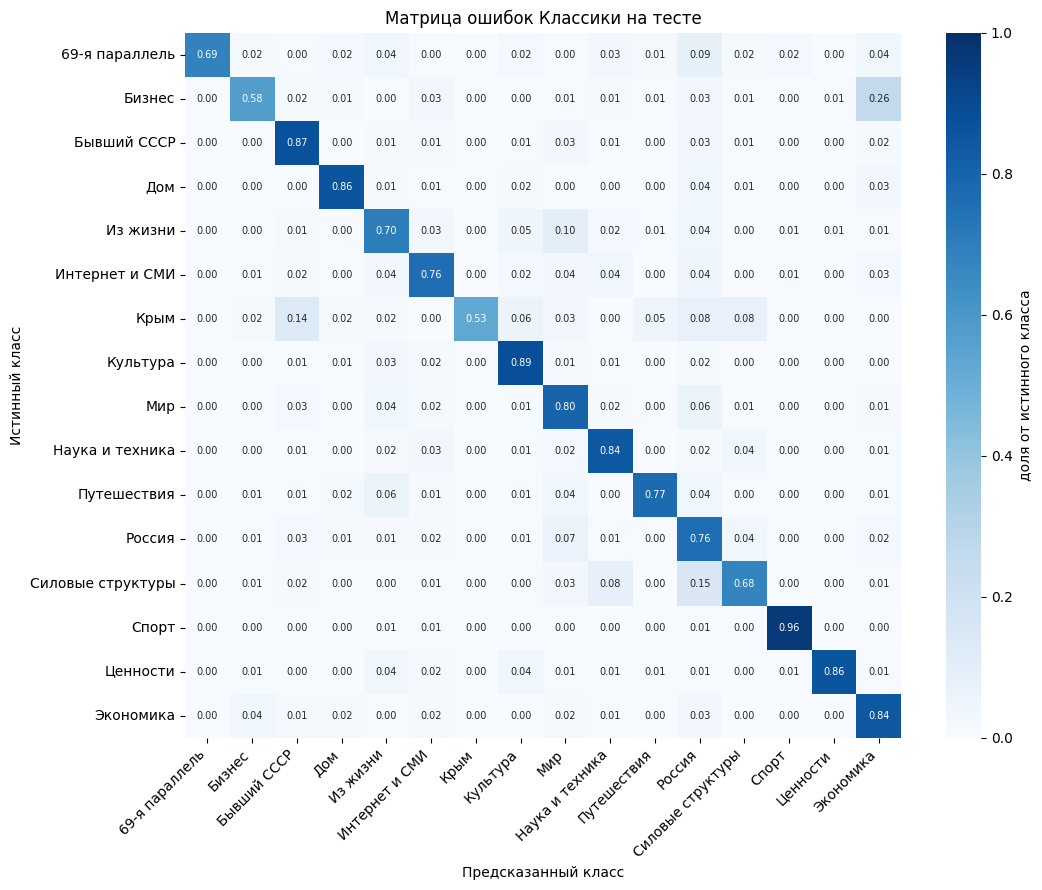

In [ ]:
cm = confusion_matrix(test_classic['topic'], test_classic['predicted_topic'], labels=classes, normalize='true')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes,
            annot_kws={'size': 7},
            cbar_kws={'label': 'доля от истинного класса'}, ax=ax)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
ax.set_title('Матрица ошибок Классики на тесте')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Проверка влияния длины текстов на классификацию у нейросети

In [ ]:
import numpy as np, gc

rng = np.random.default_rng(42)
pos = rng.choice(len(testdf), 20000, replace=False)
s_bert = testdf.iloc[pos]
s_cl   = test_classic.iloc[pos]
assert (s_bert['topic'].values == s_cl['topic'].values).all()

lens = []
texts = s_bert['text'].tolist()
for i in range(0, len(texts), 1000):
    ids = tokenizer(texts[i:i+1000], add_special_tokens=True, truncation=False)['input_ids']
    lens.extend(len(x) for x in ids)
    del ids
lens = np.array(lens)
long = lens > 256

print('доля длинных:', long.mean(), '| медиана:', np.median(lens), '| p90:', np.percentile(lens, 90))
for name, pred in [('BERT', s_bert['predicted_topic']), ('классика', s_cl['predicted_topic'])]:
    ok = pred.values == s_bert['topic'].values
    print(f'{name}: короткие {ok[~long].mean():.3f} | длинные {ok[long].mean():.3f}')

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2484 > 2048). Running this sequence through the model will result in indexing errors


доля длинных: 0.4299 | медиана: 241.0 | p90: 380.0
BERT: короткие 0.818 | длинные 0.829
классика: короткие 0.806 | длинные 0.826


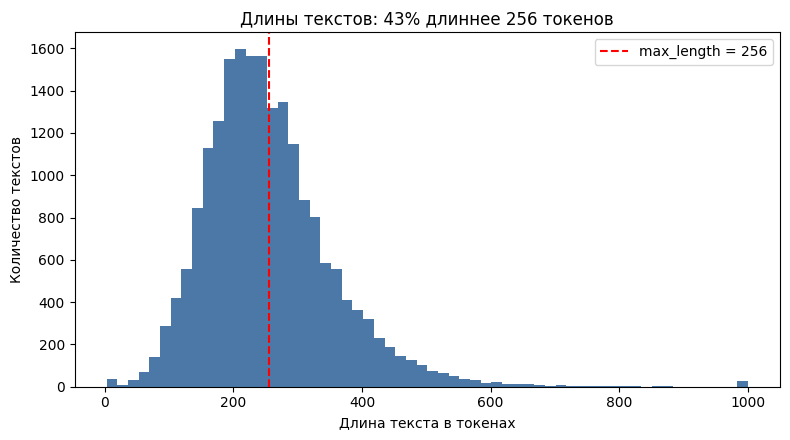

In [ ]:
import os, matplotlib.pyplot as plt
os.makedirs('images', exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(np.clip(lens, 0, 1000), bins=60, color='#4C78A8')
ax.axvline(256, color='red', linestyle='--', label='max_length = 256')
ax.set_xlabel('Длина текста в токенах')
ax.set_ylabel('Количество текстов')
ax.set_title(f'Длины текстов: {long.mean():.0%} длиннее 256 токенов')
ax.legend()
plt.tight_layout()